In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
import os
os.path.isfile('/content/drive/MyDrive/pyspark_training/yellow_tripdata_2026-01.parquet')

True

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()
spark

In [4]:
df = spark.read.parquet('/content/drive/MyDrive/pyspark_training/yellow_tripdata_2026-01.parquet')
df.show(5)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       2| 2026-01-01 00:54:04|  2026-01-01 00:59:37|              1|         0.97|         1|                 N|         239|    

> Challenge 1: Write a query combining sort, select, and filter that shows all non-airport rides with exactly one passenger.

In [5]:
df.filter('Airport_fee == 0 and passenger_count == 1')\
.select('trip_distance', 'total_amount')\
.sort('trip_distance', asceding=False)\
.show(5)

+-------------+------------+
|trip_distance|total_amount|
+-------------+------------+
|          0.0|        7.75|
|          0.0|        8.75|
|          0.0|        13.5|
|          0.0|       29.95|
|          0.0|         7.0|
+-------------+------------+
only showing top 5 rows


Challenge 2: Write some pyspark code that does some data cleansing and  apply several of the methods you have learned before.

1. Create 2 new dataframes called df_jan_2026 and df_feb_2026 from the corresponding datafiles.

In [6]:
df_jan_2026 = spark.read.parquet('/content/drive/MyDrive/pyspark_training/yellow_tripdata_2026-01.parquet')
df_feb_2026 = spark.read.parquet('/content/drive/MyDrive/pyspark_training/yellow_tripdata_2026-02.parquet')

2. Create a new dataframe called df_2026_combines as union of those 2 files.

In [7]:
df_2026_combined = df_jan_2026.union(df_feb_2026)

3. Only select the following columns from this combined dataframe and rename columns as indicated in parenthesis. Reassign the result to df_2026_combined.

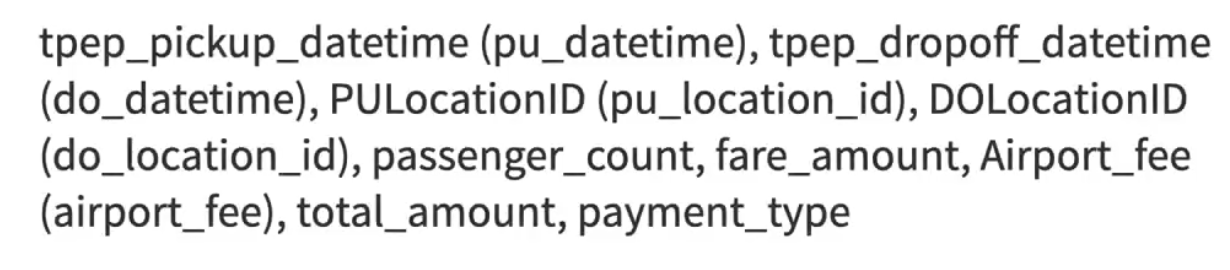

In [8]:
df_2026_combined = df_2026_combined.\
select('tpep_pickup_datetime', 'tpep_dropoff_datetime',\
        'PULocationID', 'DOLocationID', 'passenger_count', 'fare_amount',\
        'Airport_fee', 'total_amount', 'payment_type').\
withColumnsRenamed({
    'tpep_pickup_datetime': 'pu_datetime',
    'tpep_dropoff_datetime': 'do_datetime',
    'PULocationID': 'pu_location_id',
    'DOLocationID': 'do_location_id',
    'Airport_fee': 'airport_fee',
})

4. Create a new dataframe called taxi_zones from the taxi_zone_lookup.csv file.

In [9]:
taxi_zones = spark.read.option('header', 'true')\
     .csv('/content/drive/MyDrive/pyspark_training/taxi_zone_lookup.csv')

5. Join the taxi_zones dataframe onto the df_2026_combined dataframe using the do_location_id, and LocationID columns. Reassign the result of this join to df_2026_combined.

In [10]:
df_2026_combined = df_2026_combined.join(taxi_zones, df_2026_combined.do_location_id == taxi_zones.LocationID, 'left')

6. Final cleanup: Drop the superfluos LocationID, Zone, and service_zone columns, and rename the Bororugh column to pu_boro. Reassign the result to df_2026_combined.

In [11]:
df_2026_combined = df_2026_combined.drop('LocationID', 'Zone', 'service_zone')\
     .withColumnsRenamed({'Borough': 'pu_boro'})

7. Display the resulting dataframe df_2026_combined in your notebook.

In [12]:
df_2026_combined.show()

+-------------------+-------------------+--------------+--------------+---------------+-----------+-----------+------------+------------+---------+
|        pu_datetime|        do_datetime|pu_location_id|do_location_id|passenger_count|fare_amount|airport_fee|total_amount|payment_type|  pu_boro|
+-------------------+-------------------+--------------+--------------+---------------+-----------+-----------+------------+------------+---------+
|2026-01-01 00:54:04|2026-01-01 00:59:37|           239|           238|              1|        7.2|        0.0|       15.86|           1|Manhattan|
|2026-01-01 00:34:04|2026-01-01 00:39:47|           163|           162|              0|        7.9|        0.0|       13.65|           2|Manhattan|
|2026-01-01 00:57:06|2026-01-01 01:05:59|            43|           237|              0|       10.7|        0.0|       18.95|           1|Manhattan|
|2026-01-01 00:15:22|2026-01-01 00:58:10|           142|           209|              4|       38.7|        0.0| 

Challenge 3: Assume we want to determine the average total taxi ride cost for each drop-off borough. This means, how expensive are the rides depending on which borough of new york city they end in? Write code for the below following steps.

1. Load the january taxi ride data into a dataframe called taxi_jan2026 and register a temporary view with the same name.

In [13]:
taxi_jan2026 = spark.read.parquet('/content/drive/MyDrive/pyspark_training/yellow_tripdata_2026-01.parquet')
taxi_jan2026.createOrReplaceTempView('taxi_jan2026')

2. Load the taxi zone lookup data into a dataframe called taxi_lookup and register a temporary view with the same name.

In [14]:
taxi_lookup = spark.read.option('header', 'true')\
     .csv('/content/drive/MyDrive/pyspark_training/taxi_zone_lookup.csv')

taxi_lookup.createOrReplaceTempView('taxi_lookup')

3. Use PySpark SQL to left join the 2 tables on the DOLocationID and the LocationID columns.

In [15]:
query = '''
SELECT * FROM taxi_jan2026
LEFT JOIN taxi_lookup
ON taxi_jan2026.DOLocationID = taxi_lookup.LocationID;
'''

joined_df = spark.sql(query).select('DOLocationID', 'Borough', 'total_amount')

4. Using PySpark dataframe syntax, group the result by the Borough column and calculate the average total_amount using the avg method.

In [16]:
from pyspark.sql.functions import avg

result_df = joined_df.groupBy('Borough').agg(avg('total_amount').alias('avg_amount'))
result_df.show()

+-------------+------------------+
|      Borough|        avg_amount|
+-------------+------------------+
|       Queens|44.892264767063566|
|          EWR|127.38218843969248|
|      Unknown|  26.3913081781915|
|     Brooklyn|41.826533148167016|
|Staten Island|  89.1901436265709|
|          N/A|106.94886896721088|
|    Manhattan|26.403116092042005|
|        Bronx| 41.75513806557704|
+-------------+------------------+

